# **Motivation :**
I am an IT engineering undergrad student. I was studying digital logic design and I thought that can these system be replecated by ML techniques . If yes then what would be the accuracy of such system ? Can it be generalised beyound the range of training data ? I will be trying to answer these question by trying to implement a 4X1 MUX and if this a succes I will try to recreate other digital circuits using ML in upcoming notebooks.

# **What is a MUX?**
A MUX, short for "multiplexer", is a digital electronic device or circuit that is used to select one of several input signals and route it to a single output. In other words, it's a data selector or switch that can be controlled to choose which input data or signal is passed through to the output.
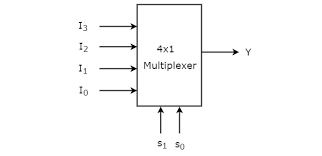

Checkout [https://en.wikipedia.org/wiki/Multiplexer](http://) for a more detailed explaination .

# **Importing Necessary Modules**

In [1]:
import numpy as np 
import pandas as pd 
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

# **Preparing Data**

In [2]:
data=make_regression(n_samples=30000, n_features=4,random_state=42,noise=2)

In [3]:
data=pd.DataFrame(np.array(data[0]),columns=["Line_0","Line_1","Line_2","Line_3"])

In [4]:
data["Selection_Stream_1"]=0
data["Selection_Stream_0"]=0

In [5]:
data.iloc[15000:30000,4]=1
data.iloc[7500:15000,5]=1
data.iloc[22500:30000,5]=1
data["OutPut"]=0
data.iloc[:7500,6]=data.iloc[:7500,0]
data.iloc[7500:15000,6]=data.iloc[7500:15000,1]
data.iloc[15000:22500,6]=data.iloc[15000:22500,2]
data.iloc[22500:30000,6]=data.iloc[22500:30000,3]

In [6]:
data

,Line_0,Line_1,Line_2,Line_3,Selection_Stream_1,Selection_Stream_0,OutPut
0,2.084029,-0.921626,-1.556238,-0.655042,0,0,2.084029
1,-0.150512,0.096378,1.225593,0.460284,0,0,-0.150512
2,-1.426869,0.451883,-0.463998,0.747872,0,0,-1.426869
3,0.356287,-1.040485,-0.220599,-0.890823,0,0,0.356287
4,0.341525,0.111786,-0.279442,-0.438156,0,0,0.341525
...,...,...,...,...,...,...,...
29995,0.297284,1.813740,-1.302119,-0.256497,1,1,-0.256497
29996,-0.575337,1.780639,1.829563,0.253184,1,1,0.253184
29997,-0.037328,0.282809,-0.318250,-0.403589,1,1,-0.403589
29998,0.485364,-0.389689,0.888398,-2.485189,1,1,-2.485189


In [7]:
X=data.iloc[:,:-1]
poly = PolynomialFeatures(degree=3,interaction_only=True)
X= poly.fit_transform(X)
y=data.iloc[:,-1]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42,shuffle=True)

# **Training The Model**

In [9]:
model=LinearRegression()
model.fit(X_train,y_train)
preds=model.predict(X_test)

In [10]:
print("MSE : ",mean_squared_error(preds,y_test))

MSE :  5.213896066003029e-30


# **Results From CV Score**
We can see that the mean square error is almost negligible . This means that it is able to act like a mux for the given data.

Let's see what equation it is using for making predictions.

# **Equation :**

In [11]:
print("Weights :",model.coef_,"\n Bias :",model.intercept_)

Weights : [-1.21142346e-17  1.00000000e+00  3.40454126e-16  2.92170988e-17
 -5.23832564e-16  1.34925974e-15  2.83962102e-16 -7.01500944e-16
 -8.16731218e-16  2.42811270e-17 -1.00000000e+00 -1.00000000e+00
 -5.10392294e-16 -8.32872183e-16  8.41886605e-16  1.00000000e+00
 -7.42105911e-16  1.00000000e+00  1.60722484e-16  8.67252375e-16
  3.49230310e-16 -3.79205214e-16  1.61093137e-16 -1.61822899e-16
  2.30347937e-16 -5.78440513e-17 -1.88926650e-16 -8.89859116e-17
  1.37049026e-15  6.10685164e-16 -3.94446433e-16  1.00000000e+00
  4.75051315e-16  2.08166817e-17 -4.71844785e-16  3.76001313e-16
  3.88578059e-16 -1.00000000e+00  2.41939715e-16  1.15185639e-15
 -1.00000000e+00  1.00000000e+00] 
 Bias : -7.323785675139582e-16


We can see that most weights and bias are almost equal to zero except for some weights . Lets see what columns associated with these non-zero weights represent

In [12]:
feature_name=poly.get_feature_names_out(['Line_0','Line_1','Line_2','Line_3','Selection_Stream_1','Selection_Stream_0'])

In [13]:
for i in range(len(model.coef_)) : 
    if round(model.coef_[i]) ==1 or round(model.coef_[i])==-1:
        print(feature_name[i],model.coef_[i])

Line_0 0.9999999999999991
Line_0 Selection_Stream_1 -1.0000000000000004
Line_0 Selection_Stream_0 -0.9999999999999993
Line_1 Selection_Stream_0 0.999999999999999
Line_2 Selection_Stream_1 0.9999999999999993
Line_0 Selection_Stream_1 Selection_Stream_0 1.0
Line_1 Selection_Stream_1 Selection_Stream_0 -0.9999999999999991
Line_2 Selection_Stream_1 Selection_Stream_0 -1.0
Line_3 Selection_Stream_1 Selection_Stream_0 1.0000000000000007


We can see that the equation for the output is approximatly :

y = Line_0 - Line_0 * Selection_Stream_1 - Line_0 * Selection_Stream_0 + Line_1 * Selection_Stream_0 + Line_2 * Selection_Stream_1 + Line_0 * Selection_Stream_1 * Selection_Stream_0 - Line_1 * Selection_Stream_1 Selection_Stream_0 - Line_2 * Selection_Stream_1 * Selection_Stream_0 + Line_0 * Selection_Stream_1 * Selection_Stream_0

If we simplify it a litle bit , it becomes :

y = (1-Selection_Stream_1) * (1-Selection_Stream_0) * Line_0 + (1-Selection_Stream_1) * Selection_Stream_0 * Line_1 + Selection_Stream_1 *  (1-Selection_Stream_0) * Line_2 + Selection_Stream_1 * Selection_Stream_0 * Line_3

Which is exactly the equation for the output of 4X1 MUX !!

# **Testing If The Model Generalises Beyond The Traing Data Or Not:**

In [14]:
point=np.array([[69,100,9,500,0,0]])
# format for input : 
#[[Line_0,Line_1,Line_2,Line_3,Selection_Stream_1,Selection_Stream_0]]
point=poly.fit_transform(point)
print("Output :",model.predict(point))

Output : [69.]


In [15]:
point=np.array([[69,100,9,500,0,1]])
# format for input : 
#[[Line_0,Line_1,Line_2,Line_3,Selection_Stream_1,Selection_Stream_0]]
point=poly.fit_transform(point)
print("Output :",model.predict(point))

Output : [100.]


In [16]:
point=np.array([[69,100,9,500,1,0]])
# format for input : 
#[[Line_0,Line_1,Line_2,Line_3,Selection_Stream_1,Selection_Stream_0]]
point=poly.fit_transform(point)
print("Output :",model.predict(point))

Output : [9.]


In [17]:
point=np.array([[69,100,9,500,1,1]])
# format for input : 
#[[Line_0,Line_1,Line_2,Line_3,Selection_Stream_1,Selection_Stream_0]]
point=poly.fit_transform(point)
print("Output :",model.predict(point))

Output : [500.]


# **Result :**
We can clearly see that polynomial regression is able to adapt the behaviour of a mux and it is able to genralise beyond the training data.

After this promising result I will try to implement more complex logical circuits using it like counters .Who knows, maybe I will make a basic computer out of regression only !

# **Happy Kaggling !!!!!**